<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


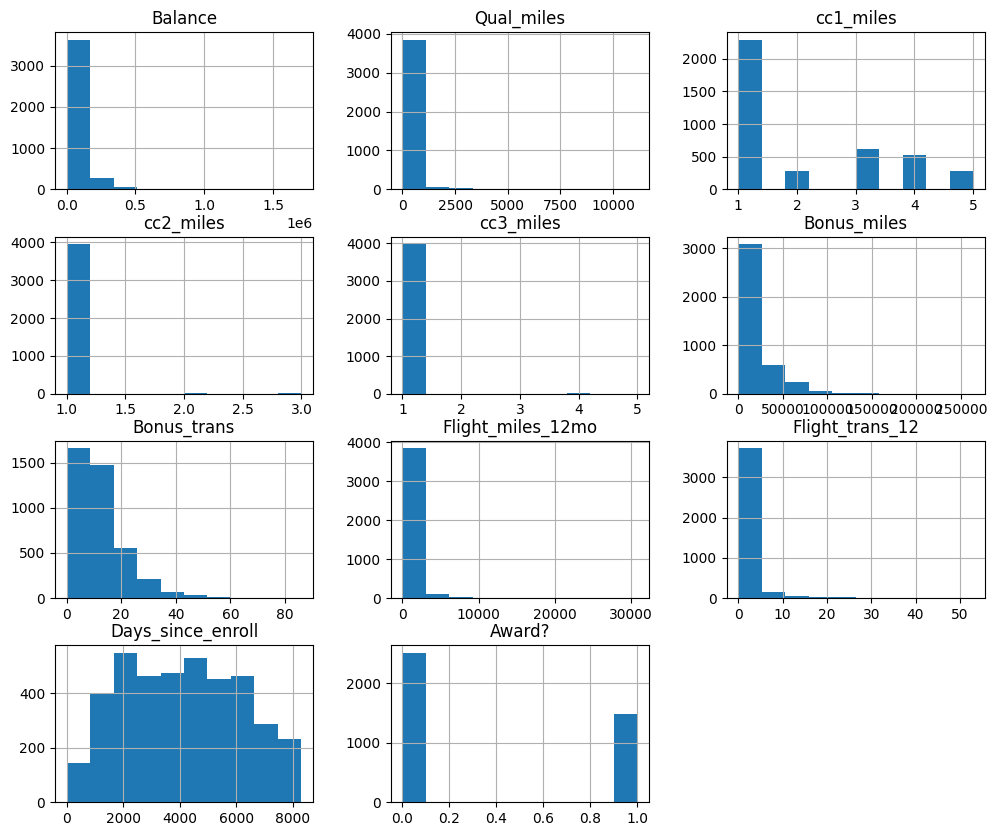

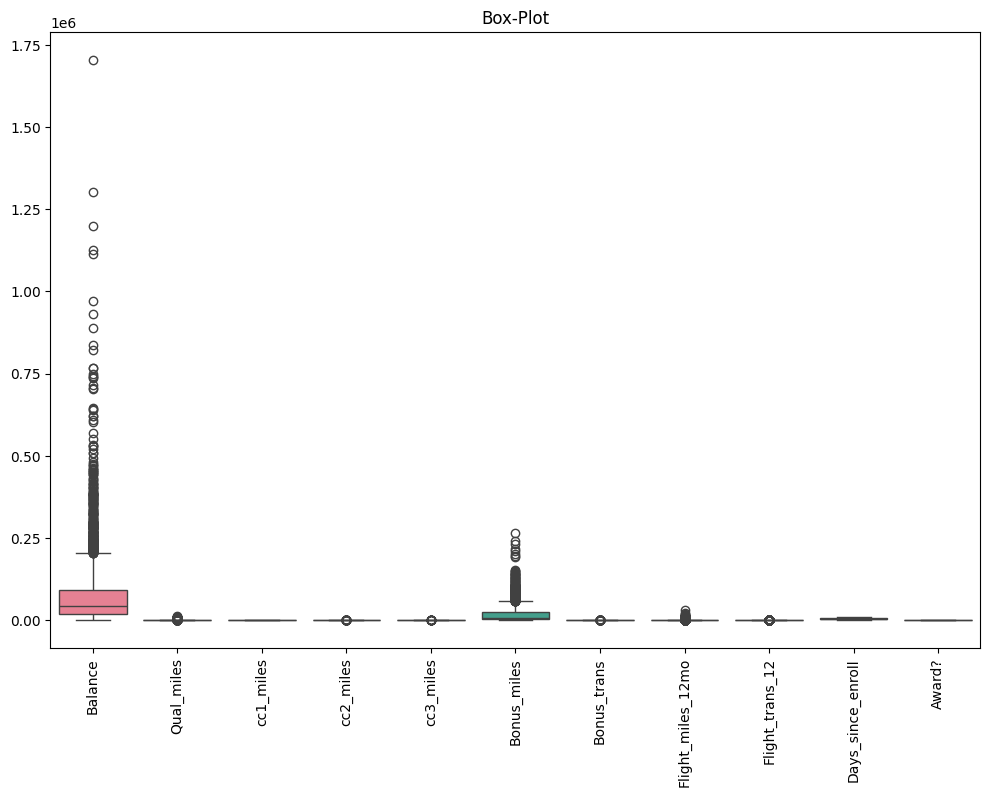

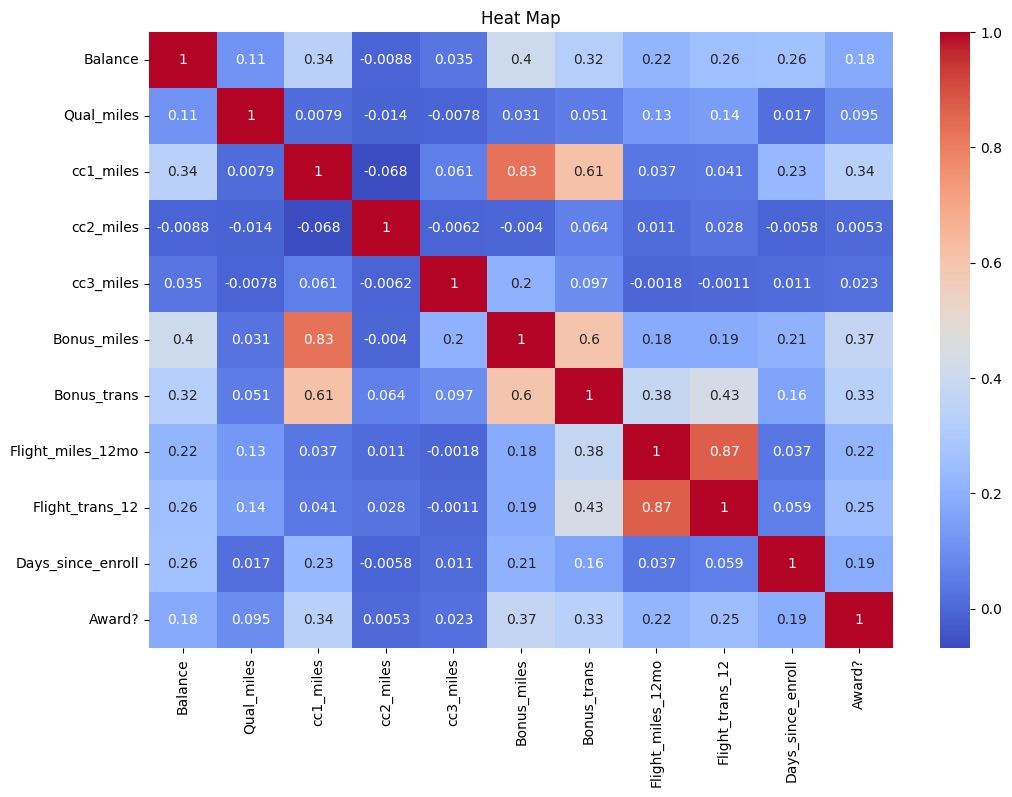

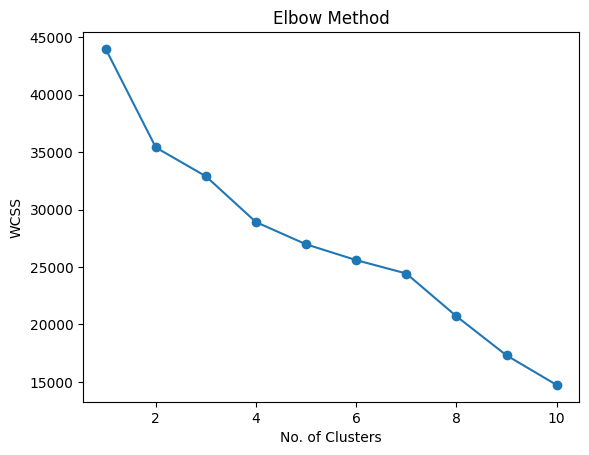

KMeans Silhouette Score: 0.19071186813310886


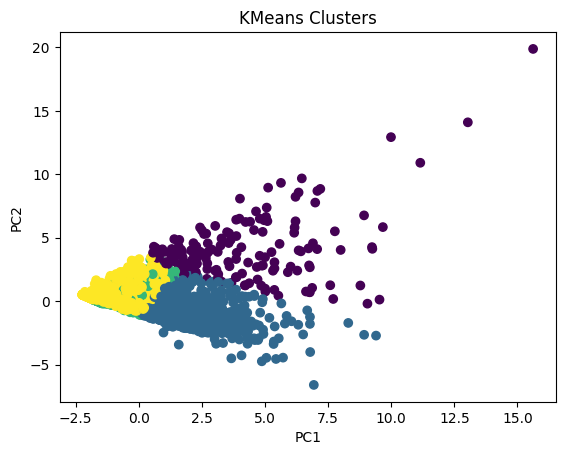

Unique DBSCAN clusters: [-1  0  1  2  3  4]
DBSCAN Silhouette Score: 0.29403795451062353


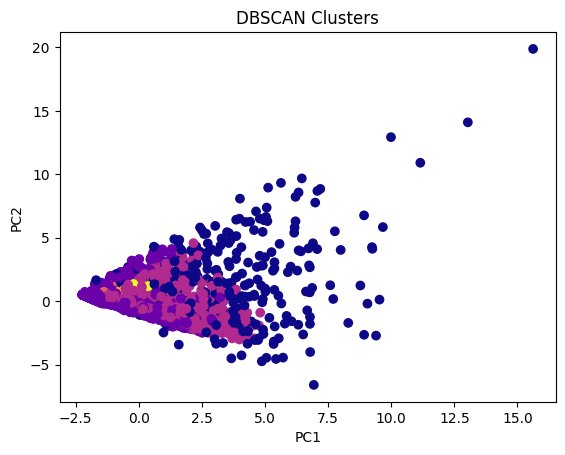


FINAL COMPARISON
KMeans Score : 0.19071186813310886
DBSCAN Score : 0.29403795451062353


In [2]:
import pandas as pd
import numpy as np

df=pd.read_excel(r"/content/EastWestAirlines.xlsx", sheet_name="data")

df.info()

df.describe()

df.head()

df.isnull().sum()

df=df.drop("ID#", axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,10))
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.title("Box-Plot")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Heat Map")
plt.show()

#Clustering requires scaling

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)

#Kmeans Clustering

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
df['KMeans_Cluster'] = kmeans_labels

print("KMeans Silhouette Score:", silhouette_score(scaled_data, kmeans_labels))

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = db_labels

print("Unique DBSCAN clusters:", np.unique(db_labels))

mask = db_labels != -1
print("DBSCAN Silhouette Score:",
      silhouette_score(scaled_data[mask], db_labels[mask]))

plt.scatter(pca_data[:,0], pca_data[:,1], c=db_labels, cmap='plasma')
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nFINAL COMPARISON")
print("KMeans Score :", silhouette_score(scaled_data, kmeans_labels))
print("DBSCAN Score :", silhouette_score(scaled_data[mask], db_labels[mask]))


In [1]:
#KMeans groups customers into fixed segments
#DBSCAN identifies loyal vs irregular customers
#DBSCAN detects outliers (important in marketing)
#KMeans better for segmentation, DBSCAN better for anomaly detection